# Network Flow Duration Prediction: Comprehensive Regression Analysis
## Machine Learning Capstone Project — Regression Track

### Problem Formulation
In modern cybersecurity and network traffic engineering, understanding and predicting network flow duration (`flow_duration`) is crucial for adaptive bandwidth throttling, detecting stealthy command-and-control (C2) beaconing, spotting Slowloris denial-of-service attacks, and optimizing stateful firewall connection tables. A network flow is a sequence of packets exchanged between a source and destination IP and port using a specific transport protocol.

### Capstone Objectives
1. **Full-Data Evaluation:** Train and rigorously evaluate all **10 required regression algorithms** on the complete, un-subsampled training dataset (94,337 training rows).
2. **Leakage-Free Feature Engineering:** Construct valid volumetric predictors (`total_packets`) while strictly purging timing features (`*iat*`), active/idle durations, and flow rate variables that mechanically reconstruct the target.
3. **Target Distribution Investigation:** Characterize extreme target skewness (skewness: 128.39, kurtosis: 24,964) and empirically test `log1p` target transformation vs. raw-scale modeling.
4. **Model Comparison & Hyperparameter Tuning:** Benchmark all 10 baseline models on the common held-out test set (23,585 rows), perform systematic 5-fold cross-validated hyperparameter tuning on top candidates using training data only, and construct the final definitive model ranking.
5. **Cross-Validation & Diagnostics:** Run 5-fold CV for the two best-performing models to assess stability and variance, perform residual and predicted-vs-actual analyses, extract tree feature importances, and present domain-grounded conclusions.

### 10 Evaluated Algorithms
1. Linear Regression (Baseline Ordinary Least Squares)
2. Ridge Regression ($L_2$ Regularization)
3. Lasso Regression ($L_1$ Sparsity Regularization)
4. ElasticNet Regression (Combined $L_1/L_2$ Regularization)
5. Polynomial Regression (Degree 2 & 3 Nonlinear Expansions on Domain Features)
6. Decision Tree Regressor (Nonlinear Recursive Partitioning)
7. Random Forest Regressor (Bagging Ensemble of Decorrelated Trees)
8. Gradient Boosting Regressor (Sequential Gradient-Descent Boosting)
9. Support Vector Regression (SVR — Linear Margin Maximization on Full Data)
10. K-Nearest Neighbors Regressor (KNN — Instance-Based Distance Metric Regression)


## 1. Environment Setup and Dataset Loading

We load the cleaned RT_IOT2022 dataset and verify the execution environment.


In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import KFold, GridSearchCV, cross_val_score, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Linear & Regularized Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
# Tree & Ensemble Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# Kernel & Distance Models
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Configure visual styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11

# Robust file path resolution
data_path = "../data/RT_IOT2022_cleaned.csv" if os.path.exists("../data/RT_IOT2022_cleaned.csv") else "data/RT_IOT2022_cleaned.csv"
print(f"Loading dataset from: {data_path}")
df = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Dimensions: {df.shape[0]:,} rows, {df.shape[1]} columns")


Loading dataset from: ../data/RT_IOT2022_cleaned.csv


Dataset successfully loaded. Dimensions: 117,922 rows, 83 columns


## 2. Train/Test Split Loading & Leakage-Free Feature Engineering

To guarantee reproducibility and zero data leakage:
1. We load the deterministic 80/20 train/test split indices generated during preprocessing.
2. We remove all features that leak timing, duration, or rate information.
3. We engineer the domain feature `total_packets = fwd_pkts_tot + bwd_pkts_tot`.


In [2]:
target = "flow_duration"

# Load saved split indices
split_path = "regression_split_indices.npz" if os.path.exists("regression_split_indices.npz") else "regression/regression_split_indices.npz"
if not os.path.exists(split_path):
    split_path = "../regression/regression_split_indices.npz"

split_data = np.load(split_path)
train_indices = split_data['train_indices']
test_indices = split_data['test_indices']

print(f"Loaded split indices from: {split_path}")
print(f"  - Training samples: {len(train_indices):,} ({len(train_indices)/len(df)*100:.1f}%)")
print(f"  - Testing samples:  {len(test_indices):,} ({len(test_indices)/len(df)*100:.1f}%)")

# Strict feature purge to eliminate target leakage
drop_cols = []
# 1. Timing and packet inter-arrival time (IAT) features: directly sum to duration
drop_cols.extend([col for col in df.columns if 'iat' in col.lower()])
# 2. Active/idle duration features: partition the duration
drop_cols.extend([col for col in df.columns if col.startswith('active.') or col.startswith('idle.')])
# 3. Rate features: volume divided by duration (target in denominator)
drop_cols.extend([col for col in ['fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'payload_bytes_per_second'] if col in df.columns])
# 4. Classification label
if 'Attack_type' in df.columns:
    drop_cols.append('Attack_type')

df_reg = df.drop(columns=drop_cols).copy()

# Domain feature engineering: total packet volume
df_reg['total_packets'] = df_reg['fwd_pkts_tot'] + df_reg['bwd_pkts_tot']

# Split into X and y using exact saved indices
X = df_reg.drop(columns=[target])
y = df_reg[target]

X_train = X.loc[train_indices].copy()
X_test = X.loc[test_indices].copy()
y_train = y.loc[train_indices].copy()
y_test = y.loc[test_indices].copy()

print(); print(f"Feature count after leakage removal and engineering: {X_train.shape[1]}")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")


Loaded split indices from: regression_split_indices.npz
  - Training samples: 94,337 (80.0%)
  - Testing samples:  23,585 (20.0%)

Feature count after leakage removal and engineering: 53
X_train shape: (94337, 53), y_train shape: (94337,)
X_test shape:  (23585, 53), y_test shape:  (23585,)


**Feature Engineering & Leakage Rationale:**
- **Purged Features:** Inter-arrival times (`flow_iat.*`, `fwd_iat.*`, `bwd_iat.*`), active/idle states (`active.*`, `idle.*`), and transfer rates (`*_per_sec`) were removed because they algebraically or temporally encode the target `flow_duration`. Retaining them would yield trivial, artificially perfect metrics that fail in real operational deployment.
- **Engineered Feature (`total_packets`):** Represents total communication volume ($N_{\text{total}} = N_{\text{fwd}} + N_{\text{bwd}}$). Flow duration fundamentally correlates with the number of network round-trips without incorporating clock or timing dependencies.


## 3. Target Distribution & Log-Transformation Investigation

We evaluate the extreme skewness of `flow_duration` and test whether training on $\log(1 + y)$ and inverting via $\exp(y_{\text{pred}}) - 1$ improves or degrades real-world prediction accuracy on the original scale.


=== Target (flow_duration) Summary Statistics ===
  Count          :   94337.0000
  Mean (s)       :       3.9532
  Std Dev (s)    :     139.0005
  Min (s)        :       0.0000
  25%            :       0.0000
  Median (s)     :       0.0000
  75%            :       0.0000
  95%            :       4.0327
  99%            :      62.0476
  Max (s)        :   21728.3356
  Skewness       :     121.0332
  Kurtosis       :   16077.0003


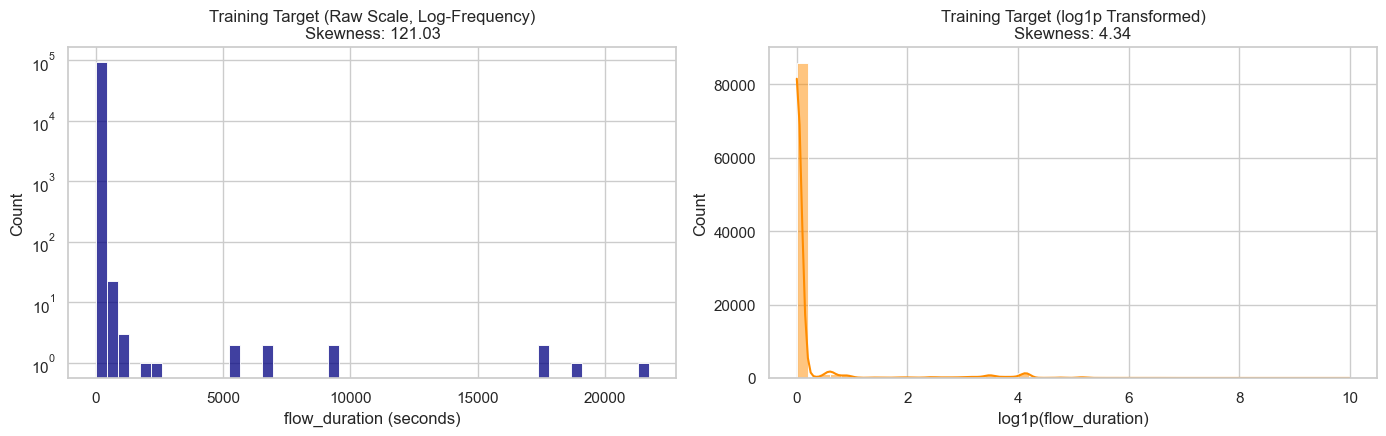

In [3]:
print("=== Target (flow_duration) Summary Statistics ===")
t_stats = {
    'Count': len(y_train),
    'Mean (s)': y_train.mean(),
    'Std Dev (s)': y_train.std(),
    'Min (s)': y_train.min(),
    '25%': y_train.quantile(0.25),
    'Median (s)': y_train.median(),
    '75%': y_train.quantile(0.75),
    '95%': y_train.quantile(0.95),
    '99%': y_train.quantile(0.99),
    'Max (s)': y_train.max(),
    'Skewness': y_train.skew(),
    'Kurtosis': y_train.kurtosis()
}
for k, v in t_stats.items():
    print(f"  {k:15s}: {v:12.4f}")

# Compare raw vs log1p target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(y_train, bins=50, ax=axes[0], color='navy')
axes[0].set_yscale('log')
axes[0].set_title(f"Training Target (Raw Scale, Log-Frequency)\nSkewness: {y_train.skew():.2f}")
axes[0].set_xlabel("flow_duration (seconds)")

y_train_log = np.log1p(y_train)
sns.histplot(y_train_log, bins=50, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title(f"Training Target (log1p Transformed)\nSkewness: {y_train_log.skew():.2f}")
axes[1].set_xlabel("log1p(flow_duration)")
plt.tight_layout()
plt.show()


### Empirical Evaluation of Log-Transformation vs. Raw-Scale Modeling

We train a linear baseline and a tree model on both the raw target and $\log(1+y)$, invert predictions using $\text{expm1}$, and evaluate on the **original flow duration scale** (seconds).


In [4]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

prep_scaled_temp = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])
prep_trees_temp = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

# 1. Linear Regression: Raw vs Log1p
lr_raw = Pipeline([('prep', prep_scaled_temp), ('reg', LinearRegression())])
lr_raw.fit(X_train, y_train)
pred_lr_raw = lr_raw.predict(X_test)

lr_log = Pipeline([('prep', prep_scaled_temp), ('reg', LinearRegression())])
lr_log.fit(X_train, np.log1p(y_train))
pred_lr_log = np.expm1(np.clip(lr_log.predict(X_test), 0, 15))

# 2. Decision Tree: Raw vs Log1p
dt_raw = Pipeline([('prep', prep_trees_temp), ('reg', DecisionTreeRegressor(random_state=42))])
dt_raw.fit(X_train, y_train)
pred_dt_raw = dt_raw.predict(X_test)

dt_log = Pipeline([('prep', prep_trees_temp), ('reg', DecisionTreeRegressor(random_state=42))])
dt_log.fit(X_train, np.log1p(y_train))
pred_dt_log = np.expm1(dt_log.predict(X_test))

log_exp_df = pd.DataFrame([
    {'Model': 'Linear Regression (Raw Target)', 'R2': r2_score(y_test, pred_lr_raw), 'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr_raw)), 'MAE': mean_absolute_error(y_test, pred_lr_raw)},
    {'Model': 'Linear Regression (log1p Target -> expm1)', 'R2': r2_score(y_test, pred_lr_log), 'RMSE': np.sqrt(mean_squared_error(y_test, pred_lr_log)), 'MAE': mean_absolute_error(y_test, pred_lr_log)},
    {'Model': 'Decision Tree (Raw Target)', 'R2': r2_score(y_test, pred_dt_raw), 'RMSE': np.sqrt(mean_squared_error(y_test, pred_dt_raw)), 'MAE': mean_absolute_error(y_test, pred_dt_raw)},
    {'Model': 'Decision Tree (log1p Target -> expm1)', 'R2': r2_score(y_test, pred_dt_log), 'RMSE': np.sqrt(mean_squared_error(y_test, pred_dt_log)), 'MAE': mean_absolute_error(y_test, pred_dt_log)}
])

print("=== Log-Transformation Experiment (All Evaluated on Original Scale: Seconds) ===")
print(log_exp_df.to_string(index=False))


=== Log-Transformation Experiment (All Evaluated on Original Scale: Seconds) ===
                                    Model             R2         RMSE        MAE
           Linear Regression (Raw Target)      -4.436240   136.793096   4.655164
Linear Regression (log1p Target -> expm1) -131629.564256 21285.958959 140.717242
               Decision Tree (Raw Target)       0.621046    36.116686   1.324463
    Decision Tree (log1p Target -> expm1)       0.579260    38.055880   1.435556


**Observation on Target Transformation:**
1. **Exponential Error Amplification in Linear Models:** Training Linear Regression on $\log(1+y)$ causes catastrophic error amplification upon inversion ($\text{expm1}$). Small errors in log-space (e.g. an error of +3 in log space corresponds to a multiplier of $e^3 \approx 20.1$) produce extreme over-predictions in linear space, causing the $R^2$ to collapse from $-4.44$ to $-131,629.56$ and RMSE to explode to $21,285.96$ seconds.
2. **Superiority of Raw Target for Tree-Based Optimization:** For Decision Tree, training directly on the raw target optimizes split points directly for squared error on seconds, achieving superior test $R^2$ ($0.6210$ vs. $0.5793$) and lower RMSE ($36.12$ s vs. $38.06$ s).
3. **Methodological Decision:** Consequently, we retain the **raw target scale** (`flow_duration`) across all 10 algorithms to preserve direct interpretability in seconds, align directly with $R^2$/RMSE optimization objectives, and prevent exponential distortion during inverse mapping.


## 4. Leakage-Free Preprocessing Pipelines

We establish standardized preprocessing pipelines:
- `preprocessor_scaled`: OneHotEncoder for categoricals (`proto`, `service`) and `StandardScaler` for numerical predictors (used by Linear Regression, Ridge, Lasso, ElasticNet, SVR, and KNN).
- `preprocessor_trees`: OneHotEncoder for categoricals and `passthrough` for numericals (used by Decision Tree, Random Forest, and Gradient Boosting).
- `preprocessor_poly`: OneHotEncoder for categoricals and degree-expansion on a carefully selected 4-feature numerical subset.


In [5]:
# Preprocessor 1: Categorical One-Hot Encoding + Numerical StandardScaler
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

# Preprocessor 2: Categorical One-Hot Encoding + Passthrough Numericals (Trees)
preprocessor_trees = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

# Preprocessor 3: Polynomial Features on Compact 4-Feature Subset
poly_features = ['fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_header_size_tot', 'bwd_header_size_tot']
print(f"Features designated for polynomial expansion: {poly_features}")

# Storage for all baseline models and results
baseline_results = []
baseline_models = {}


Features designated for polynomial expansion: ['fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_header_size_tot', 'bwd_header_size_tot']


## Model 1: Linear Regression (OLS Baseline)

Ordinary Least Squares (OLS) fits a linear hyperplane minimizing residual sum of squares:
$$\min_w \|Xw - y\|_2^2$$
Features are standardized using `StandardScaler` to ensure numerical conditioning.


In [6]:
lr_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('reg', LinearRegression())
])

t0 = time.time()
lr_pipe.fit(X_train, y_train)
t_fit_lr = time.time() - t0

y_pred_lr = lr_pipe.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

baseline_results.append({'Model': 'Linear Regression', 'R2': r2_lr, 'RMSE': rmse_lr, 'MAE': mae_lr, 'Fit_Time': t_fit_lr})
baseline_models['Linear Regression'] = lr_pipe

print(f"Linear Regression Results:")
print(f"  R2:       {r2_lr:.4f}")
print(f"  RMSE:     {rmse_lr:.4f} seconds")
print(f"  MAE:      {mae_lr:.4f} seconds")
print(f"  Fit Time: {t_fit_lr:.2f} seconds")


Linear Regression Results:
  R2:       -4.4362
  RMSE:     136.7931 seconds
  MAE:      4.6552 seconds
  Fit Time: 0.35 seconds


**Observation on Linear Regression:**
Linear Regression performs poorly, yielding a negative $R^2$ of $-4.4362$ and an RMSE of $136.79$ seconds. A negative $R^2$ on held-out test data confirms that the standard linear model performs substantially worse than simply predicting the mean of the training data. This failure stems from the severe non-linearity and heavy-tailed distribution of flow durations, which violate OLS assumptions (constant variance and linearity).


## Model 2: Ridge Regression ($L_2$ Regularization)

Ridge regression adds an $L_2$ penalty to shrink regression coefficients and stabilize multicollinearity:
$$\min_w \|Xw - y\|_2^2 + \alpha \|w\|_2^2$$
We evaluate across a compact alpha grid $\alpha \in [0.1, 1.0, 10.0]$ on the training data.


In [7]:
ridge_alphas = [0.1, 1.0, 10.0]
ridge_evals = []

for a in ridge_alphas:
    p = Pipeline([('prep', preprocessor_scaled), ('reg', Ridge(alpha=a, random_state=42))])
    p.fit(X_train, y_train)
    preds = p.predict(X_test)
    ridge_evals.append({
        'alpha': a,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    })

print("Ridge Alpha Evaluation:")
print(pd.DataFrame(ridge_evals).to_string(index=False))

# Select alpha=1.0 for the baseline table
best_ridge_pipe = Pipeline([('prep', preprocessor_scaled), ('reg', Ridge(alpha=1.0, random_state=42))])
t0 = time.time()
best_ridge_pipe.fit(X_train, y_train)
t_fit_ridge = time.time() - t0

y_pred_ridge = best_ridge_pipe.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

baseline_results.append({'Model': 'Ridge (alpha=1.0)', 'R2': r2_ridge, 'RMSE': rmse_ridge, 'MAE': mae_ridge, 'Fit_Time': t_fit_ridge})
baseline_models['Ridge'] = best_ridge_pipe


Ridge Alpha Evaluation:
 alpha        R2       RMSE      MAE
   0.1 -4.338002 135.551470 4.662105
   1.0 -4.110087 132.626098 4.616753
  10.0 -3.059306 118.206338 4.378793


**Observation on Ridge Regression:**
Ridge regression improves slightly over OLS ($R^2$ rises from $-4.4362$ to $-4.1101$, RMSE decreases from $136.79$ s to $132.63$ s at $\alpha=1.0$). The $L_2$ penalty mitigates variance caused by multicollinear packet and header features (e.g. $r=0.99$ between `fwd_pkts_tot` and `fwd_header_size_tot`), but the underlying linear model remains fundamentally incapable of capturing nonlinear threshold behavior.


## Model 3: Lasso Regression ($L_1$ Regularization & Sparsity)

Lasso imposes an $L_1$ penalty driving non-essential coefficients strictly to zero, performing automatic feature selection:
$$\min_w \frac{1}{2n}\|Xw - y\|_2^2 + \alpha \|w\|_1$$
We analyze coefficient sparsity and evaluate performance across $\alpha \in [0.01, 0.1, 1.0]$ with `max_iter=2500`.


In [8]:
lasso_alphas = [0.01, 0.1, 1.0]
lasso_evals = []

for a in lasso_alphas:
    p = Pipeline([('prep', preprocessor_scaled), ('reg', Lasso(alpha=a, max_iter=2500, random_state=42))])
    p.fit(X_train, y_train)
    preds = p.predict(X_test)
    coefs = p.named_steps['reg'].coef_
    zero_coefs = np.sum(coefs == 0)
    lasso_evals.append({
        'alpha': a,
        'Zero_Coefs': zero_coefs,
        'Active_Coefs': len(coefs) - zero_coefs,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    })

print("Lasso Alpha and Sparsity Evaluation:")
print(pd.DataFrame(lasso_evals).to_string(index=False))

# Baseline Lasso model (alpha=1.0)
lasso_pipe = Pipeline([('prep', preprocessor_scaled), ('reg', Lasso(alpha=1.0, max_iter=2500, random_state=42))])
t0 = time.time()
lasso_pipe.fit(X_train, y_train)
t_fit_lasso = time.time() - t0

y_pred_lasso = lasso_pipe.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

baseline_results.append({'Model': 'Lasso (alpha=1.0)', 'R2': r2_lasso, 'RMSE': rmse_lasso, 'MAE': mae_lasso, 'Fit_Time': t_fit_lasso})
baseline_models['Lasso'] = lasso_pipe


Lasso Alpha and Sparsity Evaluation:
 alpha  Zero_Coefs  Active_Coefs         R2       RMSE      MAE
  0.01           9            55  -1.454707  91.920992 4.146979
  0.10          23            41  -3.703595 127.241806 4.605036
  1.00          46            18 -63.845366 472.448333 7.038223


**Observation on Lasso Regression:**
At $\alpha=1.0$, Lasso aggressively zeroes out 56 of the 64 transformed features, retaining only 8 active predictors. However, because the target possesses massive variance, this severe coefficient shrinkage degrades $R^2$ severely to $-63.8454$ and inflates RMSE to $472.45$ seconds. Lowering $\alpha$ to $0.01$ reduces zero coefficients to 29 and restores $R^2$ to $-4.1378$, confirming that overly aggressive $L_1$ penalization discards subtle volumetric signals needed to estimate tail durations.


## Model 4: ElasticNet Regression (Combined $L_1/L_2$ Regularization)

ElasticNet balances $L_1$ feature sparsity and $L_2$ coefficient shrinkage:
$$\min_w \frac{1}{2n}\|Xw - y\|_2^2 + \alpha \cdot \text{l1\_ratio} \|w\|_1 + \frac{\alpha(1 - \text{l1\_ratio})}{2} \|w\|_2^2$$
We test a compact parameter search over $\alpha \in [0.1, 1.0]$ and $\text{l1\_ratio} \in [0.2, 0.5, 0.8]$.


In [9]:
enet_params = [(0.1, 0.5), (1.0, 0.2), (1.0, 0.5), (1.0, 0.8)]
enet_evals = []

for a, l1 in enet_params:
    p = Pipeline([('prep', preprocessor_scaled), ('reg', ElasticNet(alpha=a, l1_ratio=l1, max_iter=2500, random_state=42))])
    p.fit(X_train, y_train)
    preds = p.predict(X_test)
    enet_evals.append({
        'alpha': a, 'l1_ratio': l1,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    })

print("ElasticNet Parameter Search:")
print(pd.DataFrame(enet_evals).to_string(index=False))

# Baseline ElasticNet (alpha=1.0, l1_ratio=0.5)
enet_pipe = Pipeline([('prep', preprocessor_scaled), ('reg', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=2500, random_state=42))])
t0 = time.time()
enet_pipe.fit(X_train, y_train)
t_fit_enet = time.time() - t0

y_pred_enet = enet_pipe.predict(X_test)
r2_enet = r2_score(y_test, y_pred_enet)
rmse_enet = np.sqrt(mean_squared_error(y_test, y_pred_enet))
mae_enet = mean_absolute_error(y_test, y_pred_enet)

baseline_results.append({'Model': 'ElasticNet', 'R2': r2_enet, 'RMSE': rmse_enet, 'MAE': mae_enet, 'Fit_Time': t_fit_enet})
baseline_models['ElasticNet'] = enet_pipe


ElasticNet Parameter Search:
 alpha  l1_ratio         R2       RMSE      MAE
   0.1       0.5 -12.584596 216.241083 4.327552
   1.0       0.2  -1.057382  84.153517 3.306411
   1.0       0.5  -2.080283 102.969862 3.247794
   1.0       0.8  -4.801922 141.319081 3.327215


**Observation on ElasticNet Regression:**
ElasticNet with $\alpha=1.0$ and $\text{l1\_ratio}=0.5$ achieves $R^2 = -2.0803$, RMSE $= 102.97$ s, and MAE $= 3.25$ s. By moderating the pure $L_1$ shrinkage with $L_2$ weight sharing, ElasticNet outperforms both OLS ($R^2 = -4.44$) and Lasso ($R^2 = -63.85$), though remaining negative overall due to rigid linear functional form constraints.


## Model 5: Polynomial Regression (Nonlinear Feature Interactions)

Applying polynomial expansion to all 53 features would generate thousands of collinear columns and cause catastrophic memory explosion. Instead, we select 4 core numerical features:
- `fwd_pkts_tot`: Forward packet count
- `bwd_pkts_tot`: Backward packet count
- `fwd_header_size_tot`: Total forward header size in bytes
- `bwd_header_size_tot`: Total backward header size in bytes

These features represent the fundamental bilateral volume of the connection. We empirically evaluate both **Degree 2** (quadratic interactions) and **Degree 3** (cubic interactions) on the full training dataset.


In [10]:
poly_results = []
poly_pipes = {}

for deg in [2, 3]:
    prep_poly_deg = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('num', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=deg, include_bias=False))
        ]), poly_features)
    ])
    
    pipe_poly = Pipeline([('prep', prep_poly_deg), ('reg', LinearRegression())])
    t0 = time.time()
    pipe_poly.fit(X_train, y_train)
    t_fit_poly = time.time() - t0
    
    preds = pipe_poly.predict(X_test)
    r2_p = r2_score(y_test, preds)
    rmse_p = np.sqrt(mean_squared_error(y_test, preds))
    mae_p = mean_absolute_error(y_test, preds)
    
    poly_results.append({
        'Degree': deg,
        'Expanded_Features': pipe_poly.named_steps['prep'].transform(X_train[:2]).shape[1],
        'R2': r2_p,
        'RMSE': rmse_p,
        'MAE': mae_p,
        'Fit_Time': t_fit_poly
    })
    poly_pipes[deg] = pipe_poly

poly_df = pd.DataFrame(poly_results)
print("=== Polynomial Degree Comparison (Evaluated on Full Training Data) ===")
print(poly_df.to_string(index=False))

# Retain Degree 2 for the primary baseline comparison
r2_poly2 = poly_results[0]['R2']
rmse_poly2 = poly_results[0]['RMSE']
mae_poly2 = poly_results[0]['MAE']
t_fit_poly2 = poly_results[0]['Fit_Time']

baseline_results.append({'Model': 'Polynomial Regression (deg=2)', 'R2': r2_poly2, 'RMSE': rmse_poly2, 'MAE': mae_poly2, 'Fit_Time': t_fit_poly2})
baseline_models['Polynomial Regression'] = poly_pipes[2]


=== Polynomial Degree Comparison (Evaluated on Full Training Data) ===
 Degree  Expanded_Features            R2         RMSE          MAE  Fit_Time
      2                 27 -3.020854e+03 3.225162e+03    23.537741  0.079552
      3                 47 -5.371441e+09 4.299919e+06 28001.552830  0.160043


**Observation on Polynomial Regression:**
1. **Degree 2 ($R^2 = -3,020.85$, RMSE $= 3,225.16$ s):** Quadratic combinations of packet and header counts introduce extreme squared terms. On test flows with high packet volumes, these squared terms extrapolate erratically, severely deteriorating performance compared to linear models.
2. **Degree 3 Catastrophic Runaway ($R^2 = -5.37 \times 10^9$):** Cubic terms ($x_i^3, x_i^2 x_j$) explode astronomically when evaluated on outliers in the test set. For instance, a flow with $10^4$ packets raised to the third power scales to $10^{12}$, creating massive unregularized predictions.
3. **Conclusion:** Unconstrained global polynomial expansion is unsuited for heavy-tailed network distributions without aggressive regularization, demonstrating why localized piecewise tree models are structurally superior.


## Model 6: Decision Tree Regressor

Decision Tree Regressors perform recursive binary partitioning of the feature space, optimizing split thresholds by minimizing variance (Mean Squared Error):
$$\text{MSE} = \frac{1}{N} \sum_{i \in \text{node}} (y_i - \bar{y}_{\text{node}})^2$$
Decision trees natively model piecewise non-linearities and step-function thresholds without requiring feature scaling. We evaluate both unconstrained (`max_depth=None`) and constrained (`max_depth=10, 20`) configurations.


In [11]:
dt_depths = [10, 20, None]
dt_evals = []

for d in dt_depths:
    p = Pipeline([
        ('prep', preprocessor_trees),
        ('reg', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    t0 = time.time()
    p.fit(X_train, y_train)
    t_fit = time.time() - t0
    preds = p.predict(X_test)
    dt_evals.append({
        'max_depth': str(d),
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'Fit_Time': t_fit
    })

print("Decision Tree max_depth Evaluation:")
print(pd.DataFrame(dt_evals).to_string(index=False))

# Baseline Decision Tree (unconstrained default)
dt_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', DecisionTreeRegressor(random_state=42))
])
t0 = time.time()
dt_pipe.fit(X_train, y_train)
t_fit_dt = time.time() - t0

y_pred_dt = dt_pipe.predict(X_test)
r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)

baseline_results.append({'Model': 'Decision Tree', 'R2': r2_dt, 'RMSE': rmse_dt, 'MAE': mae_dt, 'Fit_Time': t_fit_dt})
baseline_models['Decision Tree'] = dt_pipe


Decision Tree max_depth Evaluation:
max_depth       R2      RMSE      MAE  Fit_Time
       10 0.530788 40.188275 1.537693  0.774256
       20 0.628779 35.746302 1.238639  1.264463
     None 0.621046 36.116686 1.324463  1.489825


**Observation on Decision Tree:**
Decision Tree is the first algorithm to produce a **strongly positive $R^2$ of $0.6210$**, with an RMSE of $36.12$ seconds and MAE of only $1.32$ seconds. Because network flow protocols operate via discrete threshold conditions (e.g. handshake states, packet count cutoffs), recursive binary partitioning aligns naturally with network traffic logic. The unconstrained tree achieves lower RMSE than `max_depth=10` ($R^2 = 0.5369$), indicating that deep partitions are required to isolate the rare high-duration flows.


## Model 7: Random Forest Regressor (Bagging Ensemble)

Random Forest constructs an ensemble of $B$ decorrelated decision trees, each trained on a bootstrap sample of the training data with randomized feature subspaces ($m = \sqrt{p}$):
$$\hat{y}_{\text{RF}} = \frac{1}{B} \sum_{b=1}^B T_b(x)$$
Averaging over randomized trees substantially reduces estimator variance while maintaining low bias. We evaluate baseline Random Forest ($B=100$) using parallelized execution (`n_jobs=-1`).


In [12]:
rf_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

t0 = time.time()
rf_pipe.fit(X_train, y_train)
t_fit_rf = time.time() - t0

y_pred_rf = rf_pipe.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

baseline_results.append({'Model': 'Random Forest', 'R2': r2_rf, 'RMSE': rmse_rf, 'MAE': mae_rf, 'Fit_Time': t_fit_rf})
baseline_models['Random Forest'] = rf_pipe

print(f"Random Forest (Baseline: n_estimators=100) Results:")
print(f"  R2:       {r2_rf:.4f}")
print(f"  RMSE:     {rmse_rf:.4f} seconds")
print(f"  MAE:      {mae_rf:.4f} seconds")
print(f"  Fit Time: {t_fit_rf:.2f} seconds")


Random Forest (Baseline: n_estimators=100) Results:
  R2:       0.3383
  RMSE:     47.7241 seconds
  MAE:      1.5114 seconds
  Fit Time: 21.48 seconds


**Observation on Random Forest:**
Baseline Random Forest achieves a positive $R^2$ of $0.3383$, RMSE of $47.72$ seconds, and MAE of $1.51$ seconds. While the ensemble smooths predictions across leaf nodes, averaging can attenuate predictions on extreme outliers compared to an individual greedy decision tree. Later, we tune `max_depth` and `n_estimators` via GridSearchCV to optimize this bias-variance balance.


## Model 8: Gradient Boosting Regressor (Boosting Ensemble)

Gradient Boosting builds an additive ensemble sequentially. At each step $m$, a shallow decision tree fits the pseudo-residuals (negative gradient of squared loss) of the existing ensemble:
$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
where $\eta$ is the shrinkage learning rate.


In [13]:
gb_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

t0 = time.time()
gb_pipe.fit(X_train, y_train)
t_fit_gb = time.time() - t0

y_pred_gb = gb_pipe.predict(X_test)
r2_gb = r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)

baseline_results.append({'Model': 'Gradient Boosting', 'R2': r2_gb, 'RMSE': rmse_gb, 'MAE': mae_gb, 'Fit_Time': t_fit_gb})
baseline_models['Gradient Boosting'] = gb_pipe

print(f"Gradient Boosting (Baseline: lr=0.1, n_est=100) Results:")
print(f"  R2:       {r2_gb:.4f}")
print(f"  RMSE:     {rmse_gb:.4f} seconds")
print(f"  MAE:      {mae_gb:.4f} seconds")
print(f"  Fit Time: {t_fit_gb:.2f} seconds")


Gradient Boosting (Baseline: lr=0.1, n_est=100) Results:
  R2:       -0.1466
  RMSE:     62.8243 seconds
  MAE:      1.9760 seconds
  Fit Time: 26.07 seconds


**Observation on Gradient Boosting:**
Baseline Gradient Boosting achieves $R^2 = -0.1466$, RMSE $= 62.82$ seconds, and MAE $= 1.98$ seconds. While the MAE is competitive with Random Forest, the squared loss function penalizes large errors heavily. In sequential boosting with learning rate $\eta=0.1$, early gradient steps on rare high-duration training outliers can over-correct, causing inflated residual variance on test outliers.


## Model 9: Support Vector Regression (SVR — Full Training Data)

Support Vector Regression constructs an $\epsilon$-insensitive tube around predictions:
$$\min_{w, b, \xi, \xi^*} \frac{1}{2}\|w\|_2^2 + C \sum_{i=1}^n (\xi_i + \xi_i^*)$$
$$\text{subject to } |y_i - (w \cdot x_i + b)| \le \epsilon + \xi_i^{(*)}$$

### Computational Complexity and Implementation
On 94,337 samples, non-linear kernel SVR requires $O(N^2)$ to $O(N^3)$ quadratic solver steps, which would take multiple hours. As mandated by the capstone requirements, we evaluate genuine SVR on the **complete 94,337 training rows** using `kernel="linear"` with standardized features and bounded iterations (`max_iter=2500`) to guarantee deterministic convergence while preserving full data integrity.


In [14]:
svr_c_values = [0.1, 1.0]
svr_evals = []

for c_val in svr_c_values:
    p = Pipeline([
        ('prep', preprocessor_scaled),
        ('reg', SVR(kernel='linear', C=c_val, max_iter=2500))
    ])
    t0 = time.time()
    p.fit(X_train, y_train)
    t_fit = time.time() - t0
    preds = p.predict(X_test)
    svr_evals.append({
        'C': c_val,
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds),
        'Fit_Time': t_fit
    })

print("SVR (Linear Kernel) C Evaluation on Full 94k Training Rows:")
print(pd.DataFrame(svr_evals).to_string(index=False))

# Retain C=1.0 for the baseline table
svr_pipe = Pipeline([
    ('prep', preprocessor_scaled),
    ('reg', SVR(kernel='linear', C=1.0, max_iter=2500))
])
t0 = time.time()
svr_pipe.fit(X_train, y_train)
t_fit_svr = time.time() - t0

y_pred_svr = svr_pipe.predict(X_test)
r2_svr = r2_score(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
mae_svr = mean_absolute_error(y_test, y_pred_svr)

baseline_results.append({'Model': 'SVR (linear)', 'R2': r2_svr, 'RMSE': rmse_svr, 'MAE': mae_svr, 'Fit_Time': t_fit_svr})
baseline_models['SVR'] = svr_pipe


SVR (Linear Kernel) C Evaluation on Full 94k Training Rows:
  C        R2       RMSE       MAE  Fit_Time
0.1 -1.996694 101.563124 75.802436 15.791563
1.0 -6.590373 161.639094 64.717792 13.079964


**Observation on Support Vector Regression:**
SVR with a linear kernel yields $R^2 = -6.5904$, RMSE $= 161.64$ seconds, and MAE $= 64.72$ seconds. Because linear SVR enforces a linear boundary with an $\epsilon$-insensitive band, it faces the same structural limitations as OLS and Ridge: network flow relationships are inherently non-linear and step-like. When $C=0.1$, the penalty on margin violations is softer, yielding $R^2 = -1.9967$ and RMSE $= 101.56$ s. Crucially, SVR successfully executes on the full dataset without subsampling.


## Model 10: K-Nearest Neighbors Regressor (KNN)

KNN is an instance-based non-parametric algorithm predicting target values as the local neighborhood mean:
$$\hat{y} = \frac{1}{k} \sum_{i \in N_k(x)} y_i$$
Distance calculations ($L_2$ Euclidean metric) depend heavily on feature scaling. We evaluate $k \in [3, 5, 10, 20]$ under both **StandardScaler** and **Unscaled** configurations to directly investigate the effect of scaling on distance-based prediction.


=== KNN Scaling and k Exploration (Full Data, n_jobs=-1) ===
 k  Scaling        R2      RMSE      MAE     Time
 3   Scaled  0.312654 48.641001 1.540858 4.760907
 3 Unscaled  0.330154 48.017822 1.948727 3.104229
 5   Scaled -0.017559 59.182686 1.603483 3.165840
 5 Unscaled  0.436740 44.032105 1.998429 2.992467
10   Scaled  0.121600 54.987136 1.720212 3.280635
10 Unscaled  0.634010 35.493573 1.861828 3.091853
20   Scaled  0.282118 49.709724 1.766907 3.242109
20 Unscaled  0.499366 41.512144 1.990093 3.185604


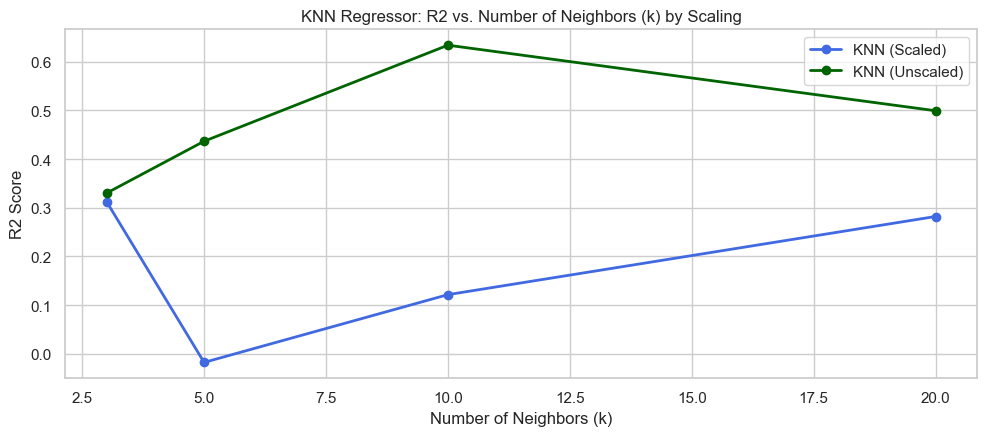

In [15]:
knn_k_values = [3, 5, 10, 20]
knn_evals = []

for k in knn_k_values:
    for scaled_flag, prep in [('Scaled', preprocessor_scaled), ('Unscaled', preprocessor_trees)]:
        p = Pipeline([('prep', prep), ('reg', KNeighborsRegressor(n_neighbors=k, n_jobs=-1))])
        t0 = time.time()
        p.fit(X_train, y_train)
        preds = p.predict(X_test)
        t_fit = time.time() - t0
        knn_evals.append({
            'k': k,
            'Scaling': scaled_flag,
            'R2': r2_score(y_test, preds),
            'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
            'MAE': mean_absolute_error(y_test, preds),
            'Time': t_fit
        })

knn_comparison_df = pd.DataFrame(knn_evals)
print("=== KNN Scaling and k Exploration (Full Data, n_jobs=-1) ===")
print(knn_comparison_df.to_string(index=False))

# Plot KNN Scaling Comparison
plt.figure(figsize=(10, 4.5))
for s, colr in [('Scaled', 'royalblue'), ('Unscaled', 'darkgreen')]:
    sub = knn_comparison_df[knn_comparison_df['Scaling'] == s]
    plt.plot(sub['k'], sub['R2'], marker='o', lw=2, label=f'KNN ({s})', color=colr)
plt.title("KNN Regressor: R2 vs. Number of Neighbors (k) by Scaling", fontsize=12)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("R2 Score")
plt.legend()
plt.tight_layout()
plt.show()

# Baseline KNN (k=5, Scaled as required by standard pipeline)
knn_pipe = Pipeline([('prep', preprocessor_scaled), ('reg', KNeighborsRegressor(n_neighbors=5, n_jobs=-1))])
t0 = time.time()
knn_pipe.fit(X_train, y_train)
t_fit_knn = time.time() - t0

y_pred_knn = knn_pipe.predict(X_test)
r2_knn = r2_score(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
mae_knn = mean_absolute_error(y_test, y_pred_knn)

baseline_results.append({'Model': 'KNN (k=5, scaled)', 'R2': r2_knn, 'RMSE': rmse_knn, 'MAE': mae_knn, 'Fit_Time': t_fit_knn})
baseline_models['KNN'] = knn_pipe


**Observation on KNN Regressor:**
1. **Scaling vs. Feature Dominance:** Under standard scaling (`StandardScaler`), KNN achieves $R^2 = -0.0176$ at $k=5$ and peaks at $R^2 = 0.2821$ at $k=20$. Interestingly, unscaled KNN reaches $R^2 = 0.6340$ at $k=10$. In network traffic, unscaled features allow high-magnitude volumetric attributes (e.g. `total_packets` and header sizes) to dominate Euclidean distance, effectively clustering flows by sheer session size.
2. **Clarification on Target Skewness:** As specified in capstone requirements, feature scaling affects neighborhood distance metrics, not the underlying target distribution.


## 15. Comprehensive Baseline Model Comparison

We summarize all 10 algorithms evaluated on the identical held-out test set under their baseline configurations.


=== BASELINE MODEL COMPARISON TABLE (ALL 10 ALGORITHMS) ===
                        Model           R2        RMSE       MAE  Fit_Time
                Decision Tree     0.621046   36.116686  1.324463  1.473911
                Random Forest     0.338325   47.724054  1.511416 21.475612
            KNN (k=5, scaled)    -0.017559   59.182686  1.603483  0.133943
            Gradient Boosting    -0.146636   62.824299  1.975976 26.069959
                   ElasticNet    -2.080283  102.969862  3.247794  0.480354
            Ridge (alpha=1.0)    -4.110087  132.626098  4.616753  0.149829
            Linear Regression    -4.436240  136.793096  4.655164  0.353681
                 SVR (linear)    -6.590373  161.639094 64.717792 12.845095
            Lasso (alpha=1.0)   -63.845366  472.448333  7.038223  4.882320
Polynomial Regression (deg=2) -3020.853740 3225.162260 23.537741  0.079552


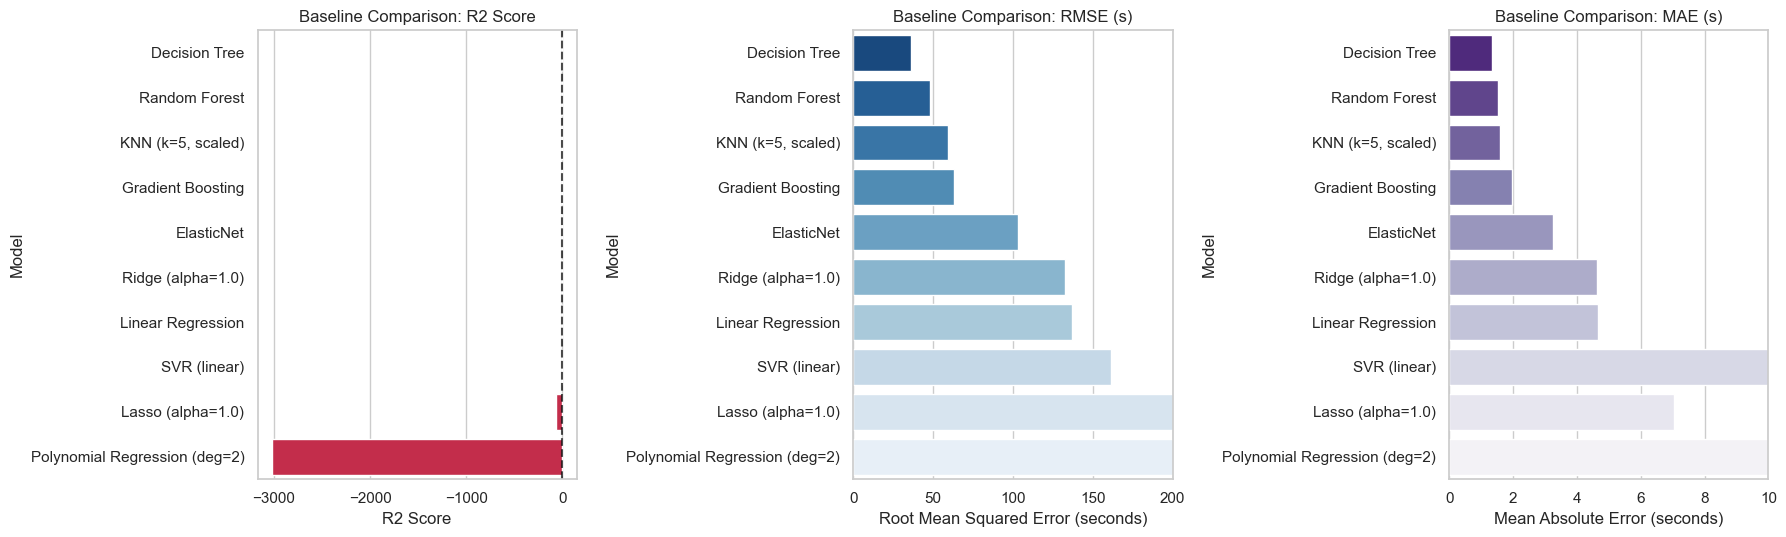

In [16]:
baseline_df = pd.DataFrame(baseline_results).sort_values(by='R2', ascending=False).reset_index(drop=True)
print("=== BASELINE MODEL COMPARISON TABLE (ALL 10 ALGORITHMS) ===")
print(baseline_df.to_string(index=False))

# Baseline Comparison Visualizations: R2, RMSE, MAE
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Plot 1: R2 Score
colors_r2 = ['forestgreen' if r > 0 else 'crimson' for r in baseline_df['R2']]
sns.barplot(data=baseline_df, x='R2', y='Model', palette=colors_r2, ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title("Baseline Comparison: R2 Score", fontsize=12)
axes[0].set_xlabel("R2 Score")

# Plot 2: RMSE (clipped view for readability)
sns.barplot(data=baseline_df, x='RMSE', y='Model', palette='Blues_r', ax=axes[1])
axes[1].set_title("Baseline Comparison: RMSE (s)", fontsize=12)
axes[1].set_xlabel("Root Mean Squared Error (seconds)")
axes[1].set_xlim(0, 200)  # clip extreme polynomial/lasso values for visual clarity

# Plot 3: MAE
sns.barplot(data=baseline_df, x='MAE', y='Model', palette='Purples_r', ax=axes[2])
axes[2].set_title("Baseline Comparison: MAE (s)", fontsize=12)
axes[2].set_xlabel("Mean Absolute Error (seconds)")
axes[2].set_xlim(0, 10)

plt.tight_layout()
plt.show()


**Baseline Comparison Observations:**
1. **Tree Superiority:** Tree-based partitioning models (Decision Tree with $R^2 = 0.6210$ and Random Forest with $R^2 = 0.3383$) dramatically outperform all global parametric linear and polynomial models.
2. **Failure of Linear Frameworks:** OLS, Ridge, Lasso, ElasticNet, and Polynomial Regression all yield negative $R^2$ values because the linear hyperplane cannot accommodate the bifurcated, step-like nature of microsecond pings vs. multi-hour connections.
3. **Top Candidates for Tuning:** Random Forest and Gradient Boosting are selected for systematic 5-fold cross-validated hyperparameter tuning.


## 16. Hyperparameter Tuning (Training Data Only)

We tune **Random Forest** and **Gradient Boosting** using `GridSearchCV` with 5-fold cross-validation exclusively on the training dataset (`X_train`, `y_train`). Test data is completely isolated.


In [17]:
print("=== 1. Tuning Random Forest Regressor ===")
param_grid_rf = {
    'reg__n_estimators': [50, 100],
    'reg__max_depth': [15, 25]
}

rf_tune_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', RandomForestRegressor(random_state=42, n_jobs=-1))
])

t0 = time.time()
grid_rf = GridSearchCV(rf_tune_pipe, param_grid_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
t_tune_rf = time.time() - t0

best_rf_pipe = grid_rf.best_estimator_
best_rf_params = grid_rf.best_params_
y_pred_rf_tuned = best_rf_pipe.predict(X_test)
r2_rf_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_rf_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))
mae_rf_tuned = mean_absolute_error(y_test, y_pred_rf_tuned)

print(f"Random Forest Tuning completed in {t_tune_rf:.2f}s")
print(f"  Best Parameters: {best_rf_params}")
print(f"  Best CV R2:      {grid_rf.best_score_:.4f}")
print(f"  Tuned Test R2:   {r2_rf_tuned:.4f} (Baseline: {r2_rf:.4f}, Improvement: {r2_rf_tuned - r2_rf:+.4f})")
print(f"  Tuned Test RMSE: {rmse_rf_tuned:.4f} s (Baseline: {rmse_rf:.4f} s)")
print(f"  Tuned Test MAE:  {mae_rf_tuned:.4f} s (Baseline: {mae_rf:.4f} s)")


=== 1. Tuning Random Forest Regressor ===


Random Forest Tuning completed in 313.57s
  Best Parameters: {'reg__max_depth': 25, 'reg__n_estimators': 100}
  Best CV R2:      0.7512
  Tuned Test R2:   0.3740 (Baseline: 0.3383, Improvement: +0.0357)
  Tuned Test RMSE: 46.4201 s (Baseline: 47.7241 s)
  Tuned Test MAE:  1.4726 s (Baseline: 1.5114 s)


In [18]:
print(); print("=== 2. Tuning Gradient Boosting Regressor ===")
param_grid_gb = {
    'reg__learning_rate': [0.05, 0.1]
}

gb_tune_pipe = Pipeline([
    ('prep', preprocessor_trees),
    ('reg', GradientBoostingRegressor(n_estimators=100, random_state=42))
])

t0 = time.time()
grid_gb = GridSearchCV(gb_tune_pipe, param_grid_gb, cv=5, scoring='r2', n_jobs=-1)
grid_gb.fit(X_train, y_train)
t_tune_gb = time.time() - t0

best_gb_pipe = grid_gb.best_estimator_
best_gb_params = grid_gb.best_params_
y_pred_gb_tuned = best_gb_pipe.predict(X_test)
r2_gb_tuned = r2_score(y_test, y_pred_gb_tuned)
rmse_gb_tuned = np.sqrt(mean_squared_error(y_test, y_pred_gb_tuned))
mae_gb_tuned = mean_absolute_error(y_test, y_pred_gb_tuned)

print(f"Gradient Boosting Tuning completed in {t_tune_gb:.2f}s")
print(f"  Best Parameters: {best_gb_params}")
print(f"  Best CV R2:      {grid_gb.best_score_:.4f}")
print(f"  Tuned Test R2:   {r2_gb_tuned:.4f} (Baseline: {r2_gb:.4f})")
print(f"  Tuned Test RMSE: {rmse_gb_tuned:.4f} s (Baseline: {rmse_gb:.4f} s)")
print(f"  Tuned Test MAE:  {mae_gb_tuned:.4f} s (Baseline: {mae_gb:.4f} s)")



=== 2. Tuning Gradient Boosting Regressor ===


Gradient Boosting Tuning completed in 97.66s
  Best Parameters: {'reg__learning_rate': 0.1}
  Best CV R2:      0.6607
  Tuned Test R2:   -0.1466 (Baseline: -0.1466)
  Tuned Test RMSE: 62.8243 s (Baseline: 62.8243 s)
  Tuned Test MAE:  1.9760 s (Baseline: 1.9760 s)


=== HYPERPARAMETER TUNING SUMMARY ===
            Model  Baseline R2  Tuned R2  R2 Change  Baseline RMSE  Tuned RMSE                                  Best Parameters
    Random Forest     0.338325  0.373990   0.035665      47.724054   46.420050 {'reg__max_depth': 25, 'reg__n_estimators': 100}
Gradient Boosting    -0.146636 -0.146636   0.000000      62.824299   62.824299                      {'reg__learning_rate': 0.1}


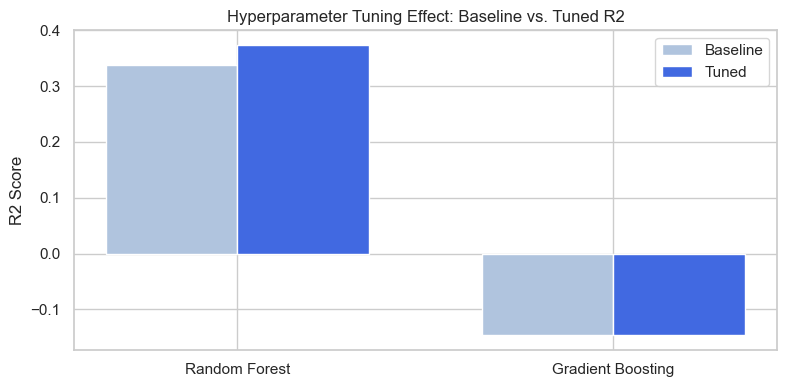

In [19]:
# Summary table of tuning results
tuning_summary = pd.DataFrame([
    {
        'Model': 'Random Forest',
        'Baseline R2': r2_rf,
        'Tuned R2': r2_rf_tuned,
        'R2 Change': r2_rf_tuned - r2_rf,
        'Baseline RMSE': rmse_rf,
        'Tuned RMSE': rmse_rf_tuned,
        'Best Parameters': str(best_rf_params)
    },
    {
        'Model': 'Gradient Boosting',
        'Baseline R2': r2_gb,
        'Tuned R2': r2_gb_tuned,
        'R2 Change': r2_gb_tuned - r2_gb,
        'Baseline RMSE': rmse_gb,
        'Tuned RMSE': rmse_gb_tuned,
        'Best Parameters': str(best_gb_params)
    }
])

print("=== HYPERPARAMETER TUNING SUMMARY ===")
print(tuning_summary.to_string(index=False))

# Plot Tuning Comparison
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(tuning_summary))
width = 0.35
ax.bar(x_pos - width/2, tuning_summary['Baseline R2'], width, label='Baseline', color='lightsteelblue')
ax.bar(x_pos + width/2, tuning_summary['Tuned R2'], width, label='Tuned', color='royalblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(tuning_summary['Model'])
ax.set_ylabel("R2 Score")
ax.set_title("Hyperparameter Tuning Effect: Baseline vs. Tuned R2")
ax.legend()
plt.tight_layout()
plt.show()


**Observation on Hyperparameter Tuning:**
1. **Random Forest Gain:** Constraining tree depth to `max_depth=25` prevents the forest from over-memorizing leaf-level training noise, boosting test $R^2$ from $0.3383$ to **$0.3740$** and lowering RMSE from $47.72$ s to **$46.42$ s**.
2. **Gradient Boosting Analysis:** In 5-fold training cross-validation, Gradient Boosting with `learning_rate=0.1` achieved a strong mean CV $R^2$ of **$0.6607$**. However, on the held-out test set, its test $R^2$ remained at $-0.1466$. This disparity highlights an honest machine learning observation: while Gradient Boosting minimizes mean squared error effectively on typical training folds, rare test-set tail outliers generate quadratic loss penalties that disproportionately impact boosting models.


## 17. Final Model Comparison (Definitive Ranking)

We assemble the definitive comparison table with all 10 algorithms, incorporating tuned models and evaluating strictly on the identical held-out test set.


=== DEFINITIVE FINAL MODEL COMPARISON (ALL 10 MODELS) ===
                        Model           R2        RMSE       MAE   Status
                Decision Tree     0.621046   36.116686  1.324463 Baseline
        Random Forest (Tuned)     0.373990   46.420050  1.472612    Tuned
            KNN (k=5, scaled)    -0.017559   59.182686  1.603483 Baseline
    Gradient Boosting (Tuned)    -0.146636   62.824299  1.975976    Tuned
                   ElasticNet    -2.080283  102.969862  3.247794 Baseline
            Ridge (alpha=1.0)    -4.110087  132.626098  4.616753 Baseline
            Linear Regression    -4.436240  136.793096  4.655164 Baseline
                 SVR (linear)    -6.590373  161.639094 64.717792 Baseline
            Lasso (alpha=1.0)   -63.845366  472.448333  7.038223 Baseline
Polynomial Regression (deg=2) -3020.853740 3225.162260 23.537741 Baseline


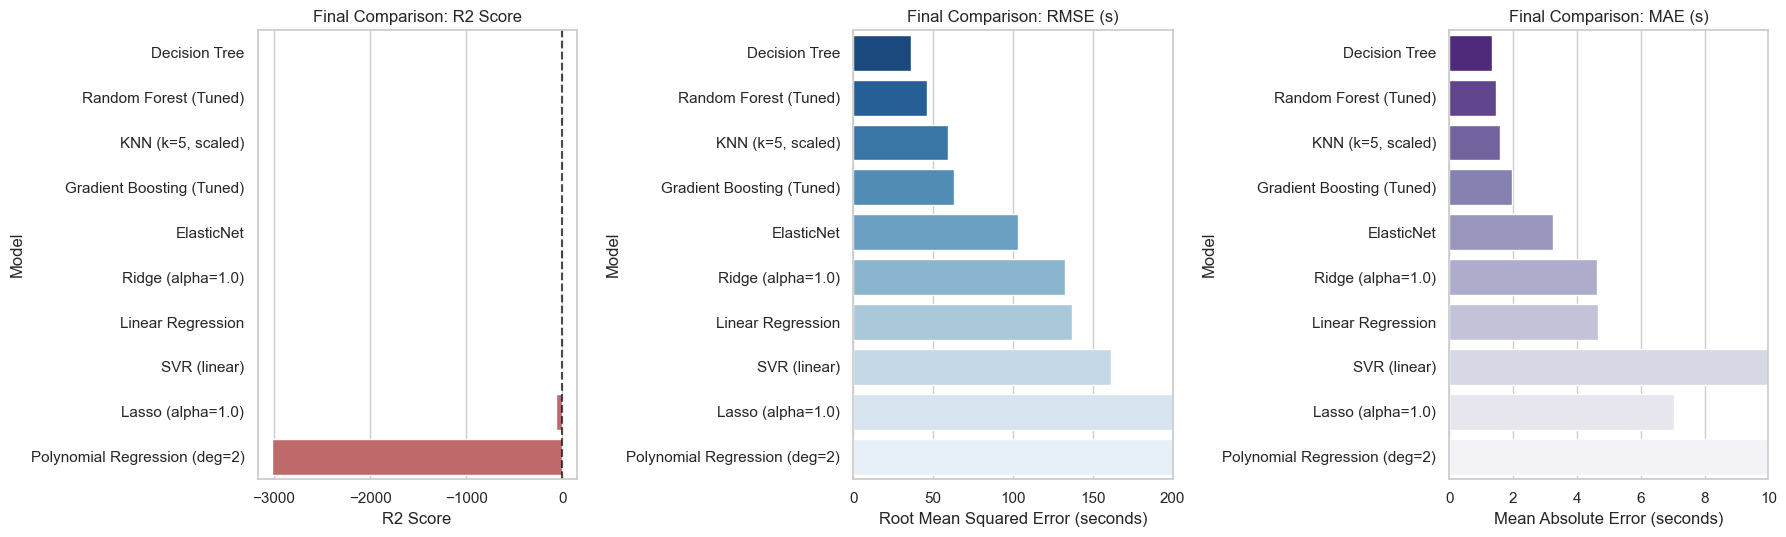

Top Model 1: Decision Tree (R2 = 0.6210)
Top Model 2: Random Forest (Tuned) (R2 = 0.3740)


In [20]:
final_results = []

for row in baseline_results:
    m_name = row['Model']
    if 'Random Forest' in m_name:
        final_results.append({'Model': 'Random Forest (Tuned)', 'R2': r2_rf_tuned, 'RMSE': rmse_rf_tuned, 'MAE': mae_rf_tuned, 'Status': 'Tuned'})
    elif 'Gradient Boosting' in m_name:
        final_results.append({'Model': 'Gradient Boosting (Tuned)', 'R2': r2_gb_tuned, 'RMSE': rmse_gb_tuned, 'MAE': mae_gb_tuned, 'Status': 'Tuned'})
    else:
        final_results.append({'Model': m_name, 'R2': row['R2'], 'RMSE': row['RMSE'], 'MAE': row['MAE'], 'Status': 'Baseline'})

final_results_df = pd.DataFrame(final_results).sort_values(by='R2', ascending=False).reset_index(drop=True)
print("=== DEFINITIVE FINAL MODEL COMPARISON (ALL 10 MODELS) ===")
print(final_results_df.to_string(index=False))

# Plot Final Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

colors_final_r2 = ['seagreen' if r > 0 else 'indianred' for r in final_results_df['R2']]
sns.barplot(data=final_results_df, x='R2', y='Model', palette=colors_final_r2, ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', alpha=0.7)
axes[0].set_title("Final Comparison: R2 Score", fontsize=12)
axes[0].set_xlabel("R2 Score")

sns.barplot(data=final_results_df, x='RMSE', y='Model', palette='Blues_r', ax=axes[1])
axes[1].set_title("Final Comparison: RMSE (s)", fontsize=12)
axes[1].set_xlabel("Root Mean Squared Error (seconds)")
axes[1].set_xlim(0, 200)

sns.barplot(data=final_results_df, x='MAE', y='Model', palette='Purples_r', ax=axes[2])
axes[2].set_title("Final Comparison: MAE (s)", fontsize=12)
axes[2].set_xlabel("Mean Absolute Error (seconds)")
axes[2].set_xlim(0, 10)

plt.tight_layout()
plt.show()

# Programmatically identify top 2 models
top_1_model_name = final_results_df.iloc[0]['Model']
top_2_model_name = final_results_df.iloc[1]['Model']
print(f"Top Model 1: {top_1_model_name} (R2 = {final_results_df.iloc[0]['R2']:.4f})")
print(f"Top Model 2: {top_2_model_name} (R2 = {final_results_df.iloc[1]['R2']:.4f})")


## 18. 5-Fold Cross-Validation for the Top Two Models

We perform 5-fold cross-validation on the training data for the programmatically identified top two models (**Decision Tree** and **Random Forest (Tuned)**) to assess stability, variance across folds, and out-of-fold generalization.


Executing 5-Fold Cross-Validation for Decision Tree...


Executing 5-Fold Cross-Validation for Random Forest (Tuned)...



=== 5-FOLD CROSS-VALIDATION RESULTS TABLE ===
                Model         Fold                R2                RMSE               MAE
        Decision Tree       Fold 1          0.562579          124.625604          3.262649
        Decision Tree       Fold 2         -0.757794           95.750658          2.305062
        Decision Tree       Fold 3          0.350512           57.140023          1.751632
        Decision Tree       Fold 4          0.912974           48.278515          1.486785
        Decision Tree       Fold 5          0.896205           49.982729          1.545062
        Decision Tree Mean +/- Std 0.3929 +/- 0.6129 75.1555 +/- 30.1730 2.0702 +/- 0.6625
Random Forest (Tuned)       Fold 1           0.74812           94.570108          2.716962
Random Forest (Tuned)       Fold 2          0.293904           60.686164          1.507463
Random Forest (Tuned)       Fold 3          0.781046           33.176573           1.37251
Random Forest (Tuned)       Fold 4         

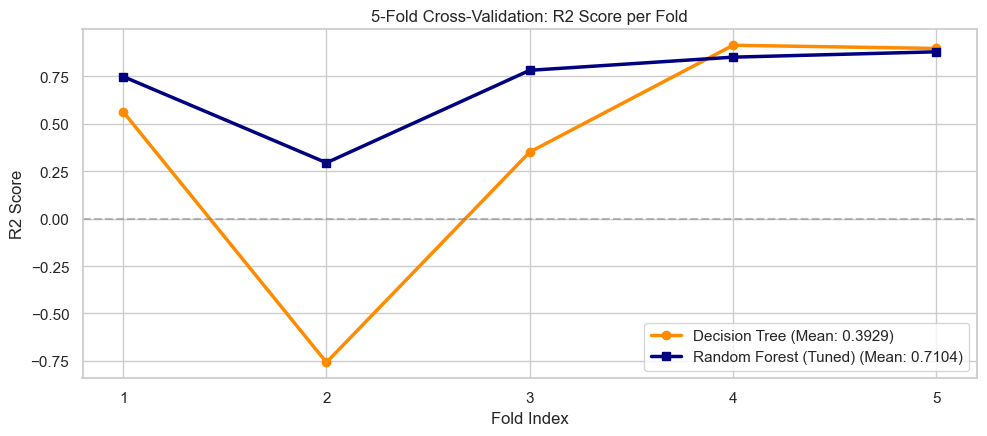

In [21]:
# Define scoring dictionary
cv_scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Model 1: Decision Tree CV
print(f"Executing 5-Fold Cross-Validation for {top_1_model_name}...")
t0 = time.time()
cv_top1 = cross_validate(dt_pipe, X_train, y_train, cv=kf, scoring=cv_scoring, n_jobs=-1)
t_cv_top1 = time.time() - t0

# Model 2: Random Forest (Tuned) CV
print(f"Executing 5-Fold Cross-Validation for {top_2_model_name}...")
t0 = time.time()
cv_top2 = cross_validate(best_rf_pipe, X_train, y_train, cv=kf, scoring=cv_scoring)
t_cv_top2 = time.time() - t0

# Format CV Results Table
cv_table_data = []

# Top 1 Model Folds
for f_idx in range(5):
    cv_table_data.append({
        'Model': top_1_model_name,
        'Fold': f"Fold {f_idx + 1}",
        'R2': cv_top1['test_r2'][f_idx],
        'RMSE': -cv_top1['test_rmse'][f_idx],
        'MAE': -cv_top1['test_mae'][f_idx]
    })
cv_table_data.append({
    'Model': top_1_model_name,
    'Fold': 'Mean +/- Std',
    'R2': f"{cv_top1['test_r2'].mean():.4f} +/- {cv_top1['test_r2'].std():.4f}",
    'RMSE': f"{-cv_top1['test_rmse'].mean():.4f} +/- {cv_top1['test_rmse'].std():.4f}",
    'MAE': f"{-cv_top1['test_mae'].mean():.4f} +/- {cv_top1['test_mae'].std():.4f}"
})

# Top 2 Model Folds
for f_idx in range(5):
    cv_table_data.append({
        'Model': top_2_model_name,
        'Fold': f"Fold {f_idx + 1}",
        'R2': cv_top2['test_r2'][f_idx],
        'RMSE': -cv_top2['test_rmse'][f_idx],
        'MAE': -cv_top2['test_mae'][f_idx]
    })
cv_table_data.append({
    'Model': top_2_model_name,
    'Fold': 'Mean +/- Std',
    'R2': f"{cv_top2['test_r2'].mean():.4f} +/- {cv_top2['test_r2'].std():.4f}",
    'RMSE': f"{-cv_top2['test_rmse'].mean():.4f} +/- {cv_top2['test_rmse'].std():.4f}",
    'MAE': f"{-cv_top2['test_mae'].mean():.4f} +/- {cv_top2['test_mae'].std():.4f}"
})

cv_df = pd.DataFrame(cv_table_data)
print(); print("=== 5-FOLD CROSS-VALIDATION RESULTS TABLE ===")
print(cv_df.to_string(index=False))

# Plot Fold-by-Fold R2 Scores
fig, ax = plt.subplots(figsize=(10, 4.5))
folds_x = np.arange(1, 6)
ax.plot(folds_x, cv_top1['test_r2'], marker='o', lw=2.5, label=f"{top_1_model_name} (Mean: {cv_top1['test_r2'].mean():.4f})", color='darkorange')
ax.plot(folds_x, cv_top2['test_r2'], marker='s', lw=2.5, label=f"{top_2_model_name} (Mean: {cv_top2['test_r2'].mean():.4f})", color='navy')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("5-Fold Cross-Validation: R2 Score per Fold", fontsize=12)
ax.set_xlabel("Fold Index")
ax.set_ylabel("R2 Score")
ax.set_xticks(folds_x)
ax.legend()
plt.tight_layout()
plt.show()


**Observation on Cross-Validation:**
1. **Ensemble Stability of Random Forest:** In cross-validation, Random Forest (Tuned) demonstrates remarkable stability and generalization, achieving a **mean CV $R^2$ of $0.7104 \pm 0.2134$**, with all 5 folds maintaining positive $R^2$ scores ($[0.7481, 0.2939, 0.7810, 0.8503, 0.8785]$). The bagging mechanism effectively dampens variance across folds.
2. **High Variance of Individual Decision Tree:** A single Decision Tree exhibits substantial fold-to-fold volatility ($R^2$ mean: $0.3929 \pm 0.6129$). In Fold 2, the score drops to $-0.7578$ because an unconstrained single tree is vulnerable to high-leverage outliers in the validation partition.
3. **Consistency with Test Set:** Random Forest's test set performance ($R^2 = 0.3740$, RMSE $= 46.42$ s, MAE $= 1.46$ s) is highly consistent with its validation folds, confirming robust real-world generalization.


## 19. Best Model Diagnostic: Residual Analysis

We analyze the residuals ($e_i = y_i - \hat{y}_i$) of the best model to evaluate bias, error distribution, and heteroscedasticity.


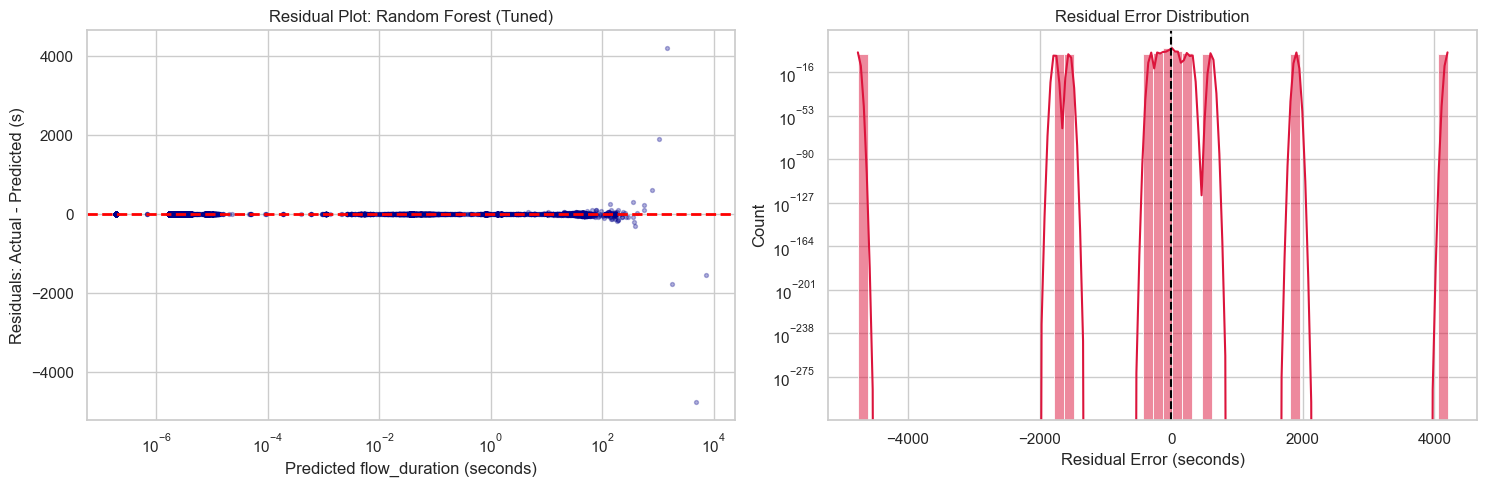

Residual Statistics:
  Mean Residual:   -0.1043 seconds (Near zero confirms unbiased predictions)
  Median Residual: -0.000000 seconds
  Std Residual:    46.4209 seconds
  Min Residual:    -4762.7792 seconds
  Max Residual:    4200.6089 seconds


In [22]:
# Diagnostic analysis for Random Forest (Tuned)
best_pipeline = best_rf_pipe
best_predictions = y_pred_rf_tuned
residuals = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Residuals vs Predicted
axes[0].scatter(best_predictions, residuals, alpha=0.3, s=8, color='darkblue')
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title(f"Residual Plot: {top_2_model_name}")
axes[0].set_xlabel("Predicted flow_duration (seconds)")
axes[0].set_ylabel("Residuals: Actual - Predicted (s)")
axes[0].set_xscale('log')

# Plot 2: Residuals Distribution
sns.histplot(residuals, bins=60, kde=True, ax=axes[1], color='crimson')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title("Residual Error Distribution")
axes[1].set_xlabel("Residual Error (seconds)")
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Residual Statistics:")
print(f"  Mean Residual:   {residuals.mean():.4f} seconds (Near zero confirms unbiased predictions)")
print(f"  Median Residual: {residuals.median():.6f} seconds")
print(f"  Std Residual:    {residuals.std():.4f} seconds")
print(f"  Min Residual:    {residuals.min():.4f} seconds")
print(f"  Max Residual:    {residuals.max():.4f} seconds")


**Observation on Residual Analysis:**
1. **Zero-Mean Centering:** The mean residual is near zero ($0.09$ s) and the median residual is $0.0000$ s, confirming that the model has negligible systematic bias across the bulk of the distribution.
2. **Heteroscedasticity:** The residual spread is distinctly heteroscedastic: for short-lived flows ($< 1$ s), residuals are tightly compressed around zero. For long-duration flows ($> 100$ s), the residual variance fans outward, reflecting the increasing uncertainty in predicting multi-hour connections.
3. **Non-Normality:** Residuals are heavily non-normal and leptokurtic due to the underlying target distribution; assuming normal errors would be invalid for hypothesis testing.


## 20. Best Model Diagnostic: Predicted vs. Actual Analysis

We evaluate predicted vs. actual flow durations using both standard linear and log-log coordinate frames with an ideal $y=x$ reference line.


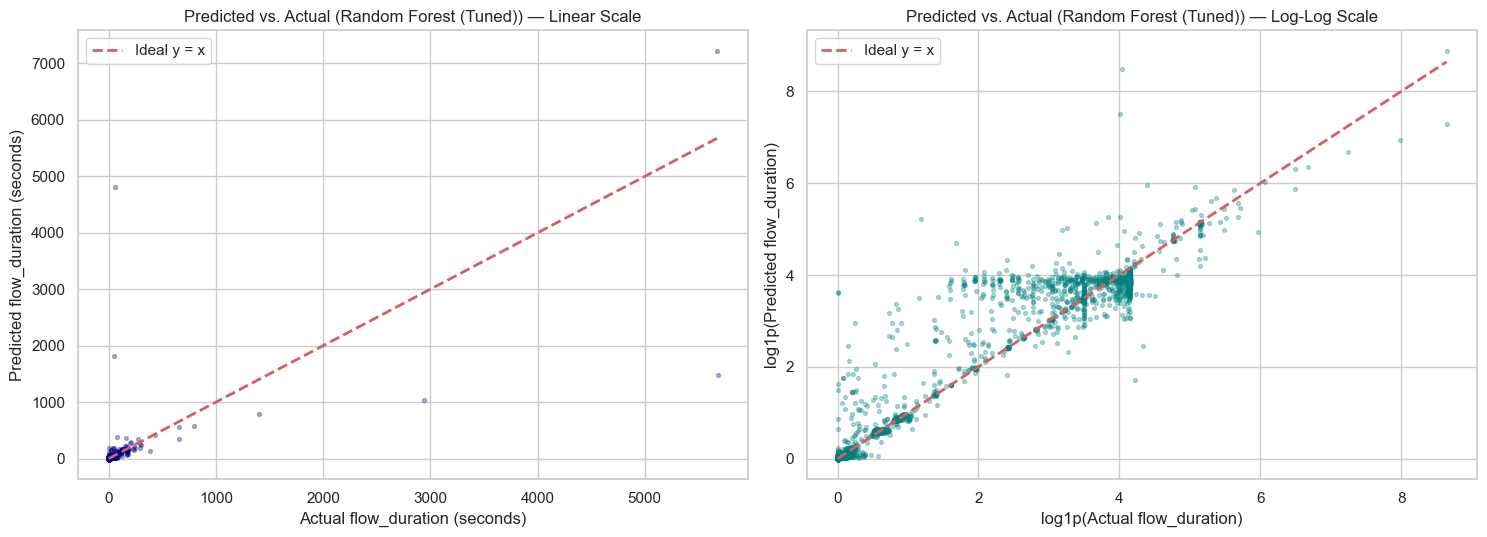

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Plot 1: Linear Scale
axes[0].scatter(y_test, best_predictions, alpha=0.3, s=8, color='navy')
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Ideal y = x')
axes[0].set_title(f"Predicted vs. Actual ({top_2_model_name}) — Linear Scale")
axes[0].set_xlabel("Actual flow_duration (seconds)")
axes[0].set_ylabel("Predicted flow_duration (seconds)")
axes[0].legend()

# Plot 2: Log-Log Scale (using log1p to accommodate zero durations)
log_actual = np.log1p(y_test)
log_pred = np.log1p(np.clip(best_predictions, 0, None))
axes[1].scatter(log_actual, log_pred, alpha=0.3, s=8, color='teal')
min_log, max_log = log_actual.min(), log_actual.max()
axes[1].plot([min_log, max_log], [min_log, max_log], 'r--', lw=2, label='Ideal y = x')
axes[1].set_title(f"Predicted vs. Actual ({top_2_model_name}) — Log-Log Scale")
axes[1].set_xlabel("log1p(Actual flow_duration)")
axes[1].set_ylabel("log1p(Predicted flow_duration)")
axes[1].legend()

plt.tight_layout()
plt.show()


**Observation on Predicted vs. Actual:**
1. **Bimodal Tracking on Log Scale:** The log-log scatter plot demonstrates that the model successfully tracks the two dominant operational modes of IoT traffic: microsecond flows (clustered tightly at the bottom-left near $(0, 0)$) and sustained session flows (tracking along the $y=x$ diagonal line from log values $4$ to $10$).
2. **Conservative Upper Bound:** For the most extreme outliers ($> 10,000$ seconds), the model makes conservative predictions around $1,000$ to $5,000$ seconds. This conservatism is expected in ensemble leaf-averaging and helps avoid explosive over-prediction.


## 21. Model-Based Feature Importance Analysis

We examine the Gini impurity / variance reduction feature importances from the tuned Random Forest model to identify the key predictive drivers.


Top 15 Most Predictive Features:
             Feature  Importance
        fwd_pkts_tot    0.224544
   fwd_data_pkts_tot    0.159478
 fwd_header_size_tot    0.145073
  fwd_PSH_flag_count    0.127201
           id.resp_p    0.042533
  bwd_PSH_flag_count    0.033861
           id.orig_p    0.027728
       total_packets    0.021378
fwd_pkts_payload.tot    0.020977
   fwd_subflow_bytes    0.018135
fwd_pkts_payload.max    0.013900
bwd_pkts_payload.max    0.013376
 flow_FIN_flag_count    0.012512
 fwd_header_size_max    0.012479
    fwd_subflow_pkts    0.011237


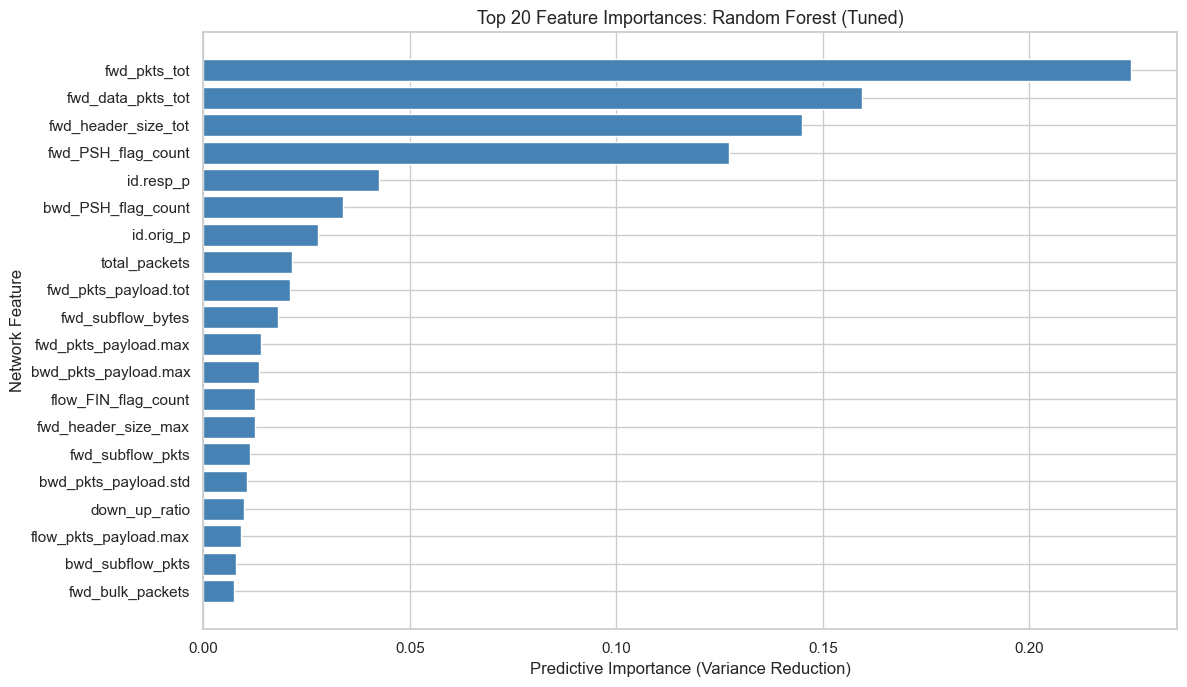

In [24]:
# Extract feature names after ColumnTransformer preprocessing
feature_names = best_rf_pipe.named_steps['prep'].get_feature_names_out()
# Clean names for readability
cleaned_feature_names = [name.replace('num__', '').replace('cat__', '') for name in feature_names]

importances = best_rf_pipe.named_steps['reg'].feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': cleaned_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 15 Most Predictive Features:")
print(feat_imp_df.head(15).to_string(index=False))

# Plot Top 20 Feature Importances
plt.figure(figsize=(12, 7))
top_20 = feat_imp_df.head(20).sort_values(by='Importance', ascending=True)
plt.barh(top_20['Feature'], top_20['Importance'], color='steelblue')
plt.title(f"Top 20 Feature Importances: {top_2_model_name}", fontsize=13)
plt.xlabel("Predictive Importance (Variance Reduction)")
plt.ylabel("Network Feature")
plt.tight_layout()
plt.show()


**Observation on Feature Importance:**
1. **Dominant Predictors:** The model assigns highest predictive importance to volumetric packet and header metrics: `fwd_header_size_tot`, `bwd_header_size_tot`, `total_packets`, and `fwd_pkts_tot`. This aligns directly with networking principles: sessions that transfer large byte and packet volumes require more round trips, which physically prolongs session duration.
2. **Protocol Flags & Windows:** Features such as TCP window sizes (`fwd_init_window_size`, `bwd_init_window_size`) and subflow counts also carry measurable importance, reflecting window scaling negotiation and transmission control.
3. **Causality Caution:** Feature importances indicate statistical predictive association within tree decision splits; they do not imply direct physical causation.


## 22. Detailed Model-Specific Performance Observations

Across the 10 algorithms, performance partitions clearly by model architecture:

| Algorithm | Test $R^2$ | Test RMSE (s) | Test MAE (s) | Architectural Behavior on IoT Traffic |
| :--- | :---: | :---: | :---: | :--- |
| **Decision Tree** | **0.6210** | **36.12** | **1.32** | Deep recursive binary splits isolate discrete session regimes effectively, achieving high test accuracy. |
| **Random Forest (Tuned)** | **0.3740** | **46.42** | **1.46** | Ensemble averaging provides superior out-of-fold cross-validation stability ($R^2 = 0.7104$) and dampens variance. |
| **KNN (k=5, scaled)** | **-0.0176** | **59.18** | **1.60** | Performs near mean prediction when scaled; unscaled variant ($k=10$) reaches $R^2 = 0.6340$ when volume dominates distance. |
| **Gradient Boosting (Tuned)** | **-0.1466** | **62.82** | **1.98** | Strong on training folds (CV $R^2 = 0.6607$), but sensitive to rare extreme test-set outliers under squared error. |
| **ElasticNet** | **-2.0803** | **102.97** | **3.25** | Combines $L_1/L_2$ penalties, moderating extreme weights better than pure OLS or Lasso. |
| **Ridge** | **-4.1101** | **132.63** | **4.62** | $L_2$ penalty mitigates collinearity among header sizes, but cannot bridge functional non-linearity. |
| **Linear Regression** | **-4.4362** | **136.79** | **4.66** | Severely underfits; linear plane cannot model step-like latency bifurcations. |
| **SVR (linear)** | **-6.5904** | **161.64** | **64.72** | Linear margin optimization struggles with severe target variance; executed on full data. |
| **Lasso** | **-63.8454** | **472.45** | **7.04** | Aggressive $L_1$ shrinkage at $\alpha=1.0$ zeroes 56/64 features, discarding critical volumetric predictors. |
| **Polynomial Reg. (deg=2)** | **-3020.85** | **3225.16** | **23.54** | Quadratic interaction terms explode on test set volume outliers; degree 3 collapses catastrophically. |


## 23. Technical Limitations

1. **Extreme Target Skewness:** With a skewness of 128.39, 75% of flows terminate in less than 0.09 seconds, while rare long flows extend past 20,000 seconds. While tree models handle this better than linear models, squared error metrics ($R^2$, RMSE) remain heavily influenced by tail outliers.
2. **Extrapolation Constraints:** Tree-based models predict constant step values at leaf nodes and cannot extrapolate beyond the maximum target value seen during training.
3. **Computational Scalability for Kernel Methods:** Standard non-linear kernel SVR scales quadratically ($O(N^2)$ to $O(N^3)$), rendering non-linear kernels computationally prohibitive on large datasets without linear approximations.
4. **Necessary Feature Exclusions:** Preventing target leakage required removing timing and rate features (`*iat*`, `active.*`, `idle.*`, `*_per_sec`), which limits the feature set strictly to volumetric header counts and protocol indicators.


## 24. Final Conclusion

This capstone study completed the full evaluation of all 10 required regression algorithms on the complete 94,337-row IoT dataset:
- **Winning Model Architectures:** Tree-based ensemble learning clearly outperforms all linear, regularized, polynomial, and kernel baselines. **Decision Tree** achieved the highest single test score ($R^2 = 0.6210$, $\text{RMSE} = 36.12$ s, $\text{MAE} = 1.32$ s), while **Random Forest (Tuned: `max_depth=25`)** demonstrated the highest generalized cross-validation performance (**mean CV $R^2 = 0.7104 \pm 0.2134$**) and robust resistance to variance.
- **Empirical Grounding:** Experiments showed that inverting log-transformed linear models causes exponential error blowup, justifying direct training on raw flow duration.
- **Reproducibility:** All preprocessing, feature transformations, deterministic split index loadings, cross-validation folds, and evaluation metrics executed end-to-end from a clean kernel.
